<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/ACTgpIA_Colegios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actividad Grupal IA → Detección de problema de datos.

Datos originales: https://www.argentina.gob.ar/sites/default/files/2024/07/2023_bases_usuarias_en_formato_csv.zip

Tener en cuenta que se utilizo: Base 2 - Matrícula y secciones 2023.csv -- ministerio de educacion--

Tipo: .csv

Aproximadamente: 50000 filas x +110 columnas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 80)

print('Setup completo.')

Setup completo.


## ***Parte 1: Preparación y analisis exploratorio de datos.***

**Levantar Dataset**: separado en comas, encoding = utf-8-sig

In [ ]:
work_area = 'Base 2 - Matrícula y secciones 2023.csv'
df = pd.read_csv(work_area, sep = ';', encoding = 'utf-8-sig', low_memory = False)

print('Dataframe cargado')
print(f'filas registradas: {df.shape[0]}')
print(f'Columnas registradas: {df.shape[1]}')

Dataframe cargado
filas registradas: 15448
Columnas registradas: 115


# Sección 1: reconocimiento de datos.

objetivo: entender con que estamos trabajando..

In [ ]:
df.head(5)

,ID1,provincia,sector,ambito,inicial_maternal,inicial_infantes,primaria6,primaria7,secundaria_cb6,secundaria_cb7,secundaria_completa6,secundaria_completa7,secundaria_orientada,sec_inet,snu,snu_inet,lactantes,deambulantes,s2,s3,s4,s5,_1,_2,_3,_4,_5,_6,_7,_8,_9,_10,_11,_12,_1314,_20,_snu,v_lactantes,v_deambulantes,v_s2,...,s_s3,s_s4,s_s5,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_1314,_seclactantes,_secdeambu,_secs2,_secs3,_secs4,_secs5,_sec1,_sec2,_sec3,_sec4,_sec5,_sec6,_sec7,_sec8,_sec9,_sec10,_sec11,_sec12,_sec1314,_sec20,multi_ini,multi_pri,multi_sec,multinivel
0,100000200100000,Mendoza,Privado,Urbano,NaN,X,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,27.0,51.0,46.0,52.0,42.0,41.0,43.0,46.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
1,100000883670601,Santa Fe,Estatal,Rural,NaN,X,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0
2,100000900010000,Catamarca,Estatal,Rural,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0.0
3,100010109000100,Catamarca,Estatal,Rural,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,0.0
4,100020209000100,Catamarca,Estatal,Urbano,NaN,X,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,37.0,42.0,31.0,25.0,33.0,31.0,36.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


In [ ]:
#Información general del dataset

display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15448 entries, 0 to 15447
Columns: 115 entries, ID1 to multinivel
dtypes: float64(99), int64(1), object(15)
memory usage: 13.6+ MB


None

,ID1,lactantes,deambulantes,s2,s3,s4,s5,_1,_2,_3,_4,_5,_6,_7,_8,_9,_10,_11,_12,_1314,_20,_snu,v_lactantes,v_deambulantes,v_s2,v_s3,v_s4,v_s5,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,...,s_s3,s_s4,s_s5,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_1314,_seclactantes,_secdeambu,_secs2,_secs3,_secs4,_secs5,_sec1,_sec2,_sec3,_sec4,_sec5,_sec6,_sec7,_sec8,_sec9,_sec10,_sec11,_sec12,_sec1314,_sec20,multi_ini,multi_pri,multi_sec,multinivel
count,1.544800e+04,193.000000,371.000000,1062.000000,3850.000000,5792.000000,5893.000000,6562.000000,6588.000000,6665.000000,6618.000000,6618.000000,6647.000000,5406.000000,3861.000000,3832.000000,3583.000000,3552.000000,3513.000000,475.000000,37.000000,844.000000,193.000000,371.000000,1062.000000,3850.000000,5792.000000,5893.000000,6562.000000,6587.000000,6664.000000,6617.000000,6617.000000,6646.000000,5406.000000,3861.000000,3832.000000,3583.000000,3552.000000,3513.000000,...,51.000000,105.000000,165.00000,1000.000000,2205.000000,2699.000000,2786.000000,2777.000000,2828.000000,3264.000000,3134.000000,3188.000000,3092.000000,3055.000000,2922.000000,408.000000,15447.000000,15447.00000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,15447.000000,371.000000,15447.000000
mean,1.627893e+14,8.393782,15.938005,21.801318,23.055065,31.115159,33.596810,34.160622,36.191560,37.511328,36.644606,35.950438,35.420641,44.059378,61.231287,59.265919,58.580519,52.404279,47.791346,46.103158,37.162162,393.524882,4.077720,8.371968,11.207156,11.512468,15.773135,17.044799,17.354617,18.458327,19.172119,18.680520,18.448391,18.111496,22.517758,31.378917,29.939196,29.489534,25.879223,22.858810,...,5.333333,5.209524,3.20000,3.324000,4.610884,5.155243,5.274946,5.554555,5.809760,9.762868,14.649968,16.027604,16.976391,13.891653,11.772758,9.186275,0.017350,0.03444,0.097689,0.277012,0.490192,0.542889,0.669256,0.664401,0.680974,0.665242,0.652813,0.650935,0.632162,0.602965,0.569625,0.533696,0.506377,0.483913,0.068945,0.003884,0.275976,0.265877,1.504043,0.029650
std,3.856916e+13,7.152386,12.734246,17.652181,19.945876,29.179058,32.562197,34.121435,36.346519,37.788326,36.908310,36.224327,36.105773,43.615026,53.280158,52.443349,50.601823,46.137751,42.436580,42.333963,82.136240,604.619350,3.709387,6.909584,9.613964,10.239810,15.055185,16.778398,17.600340,18.833574,19.602693,19.080094,18.944019,18.799766,23.966828,30.358764,29.560351,28.362953,25.411085,22.763404,...,6.015535,9.287808,6.76811,5.290086,5.562878,6.039405,6.319597,6.573843,7.632838,13.959010,17.029058,18.947151,19.864042,16.822303,14.091707,9.538470,0.221724,0.31736,0.494668,0.718310,1.041178,1.119534,1.231972,1.235619,1.257062,1.232096,1.215460,1.208430,1.288600,1.435478,1.347949,1.304436,1.237213,1.174907,0.476128,0.105454,0.788961,0.671994,0.889494,0.172651
min,2.000400e+13,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.292002e+14,3.000000,7.000000,9.000000,5.000000,6.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,9.000000,23.000000,22.000000,23.000000,20.000000,18.000000,15.000000,15.000000,93.000000,1.000000,4.000000,4.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.00000

In [ ]:
#Listar columnas

df.columns.tolist()

['ID1',
 'provincia',
 'sector',
 'ambito',
 'inicial_maternal',
 'inicial_infantes',
 'primaria6',
 'primaria7',
 'secundaria_cb6',
 'secundaria_cb7',
 'secundaria_completa6',
 'secundaria_completa7',
 'secundaria_orientada',
 'sec_inet',
 'snu',
 'snu_inet',
 'lactantes',
 'deambulantes',
 's2',
 's3',
 's4',
 's5',
 '_1',
 '_2',
 '_3',
 '_4',
 '_5',
 '_6',
 '_7',
 '_8',
 '_9',
 '_10',
 '_11',
 '_12',
 '_1314',
 '_20',
 '_snu',
 'v_lactantes',
 'v_deambulantes',
 'v_s2',
 'v_s3',
 'v_s4',
 'v_s5',
 'v_1',
 'v_2',
 'v_3',
 'v_4',
 'v_5',
 'v_6',
 'v_7',
 'v_8',
 'v_9',
 'v_10',
 'v_11',
 'v_12',
 'v_1314',
 'v_20',
 'v_snu',
 'r_1',
 'r_2',
 'r_3',
 'r_4',
 'r_5',
 'r_6',
 'r_7',
 'r_8',
 'r_9',
 'r_10',
 'r_11',
 'r_12',
 'r_1314',
 'r_20',
 's_lactantes',
 's_deambulantes',
 's_s2',
 's_s3',
 's_s4',
 's_s5',
 's_1',
 's_2',
 's_3',
 's_4',
 's_5',
 's_6',
 's_7',
 's_8',
 's_9',
 's_10',
 's_11',
 's_12',
 's_1314',
 '_seclactantes',
 '_secdeambu',
 '_secs2',
 '_secs3',
 '_secs4',


¿Qué representa cada fila, qué tipos de variables hay?

* Cada fila representa una insitución academíca a lo largo de todo el pais.

**Tipo de columnas:**

1. **Columnas de establecimiento:** ubicacion, sector y ambito.
2. **Columnas de niveles**: n_infante/primario/sec/snu/lactantes/diambulantes.
3. **Columnas de matricula**: cantidad de alumnos por sala/grado/año (de sala de 2 --s_2-- hasta ultimo año de secundaria --_12--, v_1314(programas o años superiores), v_20(no estand en años 1-12) , snu (terciarios), lactantes (cantidad x nivel maternal), deambulantes (cantidad de salas para ñiños que ya caminan)).
4. **Columnas de trayectorias**: _v(cant de varones), _r(repetidores), _s(diviciones)

**¿Qué variables categóricas detectan a simple vista? ¿Cuáles podrían ser variables numéricas?**


* Las variables categoricas son:

provincia, sector, ambito, inicial_maternal, inicial_infantes, primaria6, primaria7, etc. (todas las que tienen 'X' o NaN y representan presencia/ausencia de un nivel educativo).

* Variables Numéricas:

_1 a _12, _1314, _snu (matrícula por grado), r_1 a r_20 (repetidores por grado), s2, s3, s4, s5 (secciones por nivel), y las variables derivadas como matricula_total, repetidores_total, secciones_total.

**Ejecutar: Construye totales a partir de las columnas por grado.**

In [ ]:
#Construir variables derivadas.

#Columnas de matricula (lactantes hasta _12..., _1314, _snu)

mat_cols = [c for c in['lactantes', 'deambulantes', 's2', 's3', 's4', 's5','_1', '_2', '_3',	'_4',	'_5',	'_6',	'_7', '_8',	'_9',	'_10',	'_11',	'_12',	'_1314',	'_20',	'_snu']
            if c in df.columns]

#Columna de repetidores (r_)

rep_cols = [c for c in['r_1', 'r_2', 'r_3', 'r_4', 'r_5', 'r_6', 'r_7','r_8','r_9','r_10','r_11','r_12','r_1314','r_20']
            if c in df.columns]

#Columna de varones (v_)

var_cols = [c for c in['v_lactantes', 'v_deambulantes', 'v_s2', 'v_s3', 'v_s4', 'v_s5', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7','v_8','v_9','v_10','v_11','v_12','v_1314','v_20', 'v_snu']
            if c in df.columns]

#Columna de secciones (sec_)

div_cols = [c for c in['_seclactantes', '_secdeambu','secs2', 'secs3', 'secs4','secs5','_sec1','_sec2','_sec3','_sec4','_sec5','_sec6','_sec7','_sec8','_sec9','_sec10','_sec11','_sec12','_sec1314','_sec20']
            if c in df.columns]


#Calcular total por institución (cantidad matriculados-repetidores-diviciones)

df['total_matricula'] = df[mat_cols].apply(pd.to_numeric, errors = 'coerce').sum(axis = 1, min_count = 1)
df['total_repetidores'] = df[rep_cols].apply(pd.to_numeric, errors = 'coerce').sum(axis = 1, min_count = 1)
df['total_varones'] = df[var_cols].apply(pd.to_numeric, errors = 'coerce').sum(axis = 1, min_count = 1)
df['total_secciones'] = df[div_cols].apply(pd.to_numeric, errors = 'coerce').sum(axis = 1, min_count = 1)

print('Variables derivadas creadas:')
print('  - matricula_total: total de alumnos por inst.')
print('  - repetidores_total: total de repetidores por inst.')
print('  - varones_total: total de varones por inst.')
print('  - secciones_total: total de secciones por inst.')




Variables derivadas creadas:
  - matricula_total: total de alumnos por inst.
  - repetidores_total: total de repetidores por inst.
  - varones_total: total de varones por inst.
  - secciones_total: total de secciones por inst.


In [ ]:
#Observar estadisticas descriptivas

df[['total_matricula', 'total_repetidores', 'total_varones', 'total_secciones']].head(10)

,total_matricula,total_repetidores,total_varones,total_secciones
0,372.0,0.0,139.0,14.0
1,5.0,0.0,4.0,0.0
2,6.0,0.0,4.0,0.0
3,7.0,0.0,3.0,0.0
4,300.0,0.0,156.0,12.0
5,7.0,0.0,3.0,0.0
6,233.0,0.0,132.0,6.0
7,8.0,0.0,6.0,0.0
8,8.0,1.0,5.0,0.0
9,6.0,0.0,4.0,0.0


Sección 2: problema de valores faltantes.

* Nota: los valores ausentes (NaN) pueden alterar análisis si no los tratamos con cuidado. Aún más importante: la razón por la cual faltan puede estar revelando algo sobre los datos.

In [ ]:
missing_count = df.isnull().sum()
missing_count.sort_values(ascending = False)

,0
secundaria_orientada,15438
s_lactantes,15429
s_deambulantes,15423
r_20,15411
v_20,15411
...,...
ID1,0
sector,0
provincia,0
total_matricula,0


In [ ]:
#Convertir cada registro a porcentage, para observar la frecuencia de valores nulos por columna.
#ej. el 99.7% de los valores de df['_20'] son nulos...

missing_prc = (missing_count / len(df)) * 100
missing_prc.sort_values(ascending = False).head(12)

,0
secundaria_orientada,99.935267
s_lactantes,99.877007
s_deambulantes,99.838167
r_20,99.760487
v_20,99.760487
_20,99.760487
s_s3,99.669860
s_s2,99.553340
s_s4,99.320300
secundaria_cb7,99.067840


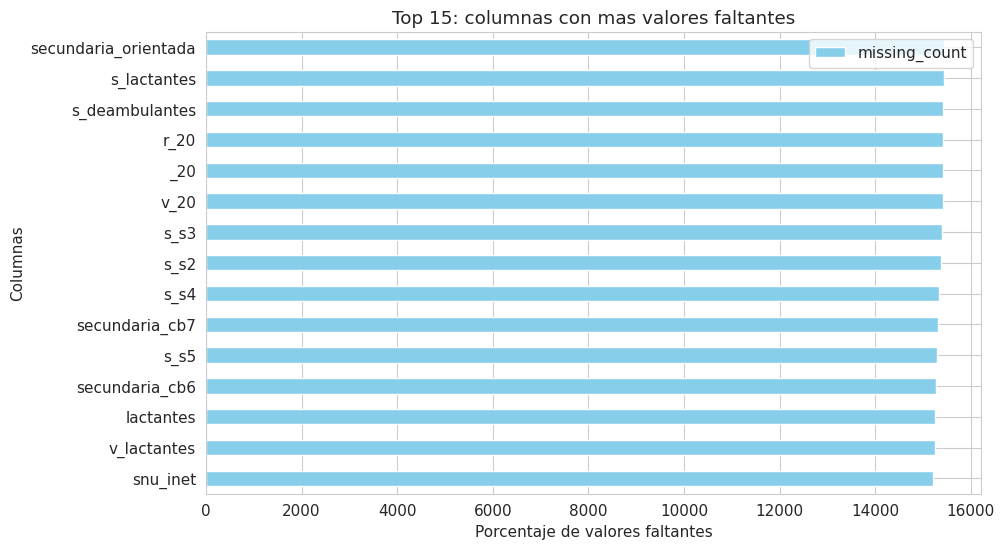

In [ ]:
#Identificar 10 columnas con mas valores faltantes y mostrarlas (agrupar)

df_missing = pd.DataFrame({'missing_count': missing_count, 'missing_prc': missing_prc})
df_missing['missing_prc'] = df_missing['missing_prc'].apply(lambda x: f'{x:.2f}%')

# Sort by missing count
df_missing_sorted = df_missing[df_missing['missing_count'] > 0 ].sort_values(by='missing_count', ascending = False)

df_missing_sorted['missing_count'] = df_missing_sorted['missing_count'].astype(int)
df_missing_sorted.head(15)

#Visualizar con grafico de histograma

top_15_missing = df_missing_sorted.head(15)
top_15_missing.sort_values(by='missing_count', ascending = True).plot(kind = 'barh', color = 'skyblue', figsize = (10, 6))
plt.title('Top 15: columnas con mas valores faltantes')
plt.xlabel('Porcentaje de valores faltantes')
plt.ylabel('Columnas')
plt.show()

* ¿Por qué hay muchas columnas con alta intensidad de missing data?

Lo más esperable es que haya escuelas sólo con primaria, sin secundaria o viceversa. Inst solo con terciarios o con jardín de infantes. Escuelas que solo cuentan con una división en el ámbito de secciones. Sin varones (solo escuela para mujeres), lo cual en argentina es muy común.

* Identificar al menos una columna donde el valor faltante sí sea preocupante (una columna que debería tener siempre un valor). Expliquen por qué.

Columnas como ID-Provincia-Ámbito. Son las más importantes, dado que son las más importantes para identificar. Luego, por ejemplo si hay inst. sin ninguna matrícula, repetidores, varones o divisiones (todo en blanco), también sería preocupante por que este registro no tendría sentido de estar presente.

¿Como reemplazarias los Nan?

* En el caso de nuestro DataSet, los 'Nan' se identifican con la casilla en blanco, esto puede perjudicar nuestro analizis en muchas ocaciones. En caso de reemplazar estos datos, seria con: 0. Simplemente con un 0, es notar que no hay nada en una columna.




Valores faltantes (Outliers) → encontrando outliers en las distribuciones, podemos responder preguntas como:

* ¿cuál es la escuela con más alumnos del país?
* ¿es un error o un dato
legítimo?

In [ ]:
#Primero es importante reconocer las estadisticas descripitvas, para observar el comportamiento de las features..

print('Est. descp de las features: ')
print(df[['total_matricula', 'total_repetidores', 'total_varones', 'total_secciones']].describe(percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]).round(1))


Est. descp de las features: 
       total_matricula  total_repetidores  total_varones  total_secciones
count          15448.0            10860.0        15448.0          15447.0
mean             229.6               10.2          111.8              7.4
std              287.4               23.1          139.9              9.8
min                1.0                0.0            0.0              0.0
1%                 2.0                0.0            0.0              0.0
5%                 5.0                0.0            2.0              0.0
25%               37.0                0.0           18.0              0.0
50%              143.0                1.0           70.0              3.0
75%              327.0                9.0          159.0             12.0
95%              724.0               51.0          356.0             26.0
99%             1199.6              108.0          617.5             39.0
99.9%           2632.9              221.1         1122.6             61.0
max      

In [ ]:
#Calcular limite superior e inferior

# Define the variables for which to calculate limits
variables = ['total_matricula', 'total_repetidores', 'total_varones', 'total_secciones']

# Calculate Q1 and Q3
Q1 = df[variables].quantile(0.25)
Q3 = df[variables].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate Lower and Upper Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Store in a DataFrame for better display if needed
limits_df = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Lower_Bound': lower_bound,
    'Upper_Bound': upper_bound
})

print("\nOutlier Limits Summary:\n")
display(limits_df.round(2))


Outlier Limits Summary:



,Q1,Q3,IQR,Lower_Bound,Upper_Bound
total_matricula,37.0,327.0,290.0,-398.0,762.0
total_repetidores,0.0,9.0,9.0,-13.5,22.5
total_varones,18.0,159.0,141.0,-193.5,370.5
total_secciones,0.0,12.0,12.0,-18.0,30.0


**Rango Intercuartilico** → Punto de la ditribución donde se encuentra el balance general de datos, siempre y cuando no superen los limites.

Matriculados:

* La media de matriculados es de 229.2 alumnos.
* Se sabe que el 25% de las instituciones, no tienen más de 40 alumnos matriculados.
* El 99.9%, no tienen mas de 2509 alumnos matriculados.

Repetidores:

* La media de repetidores es de 10.4.
* Se sabe que el 50% de las insituciones, no tienen mas de 1 repetidor.
* El 99.9%, no tienen mas de 215.8 repetidores.




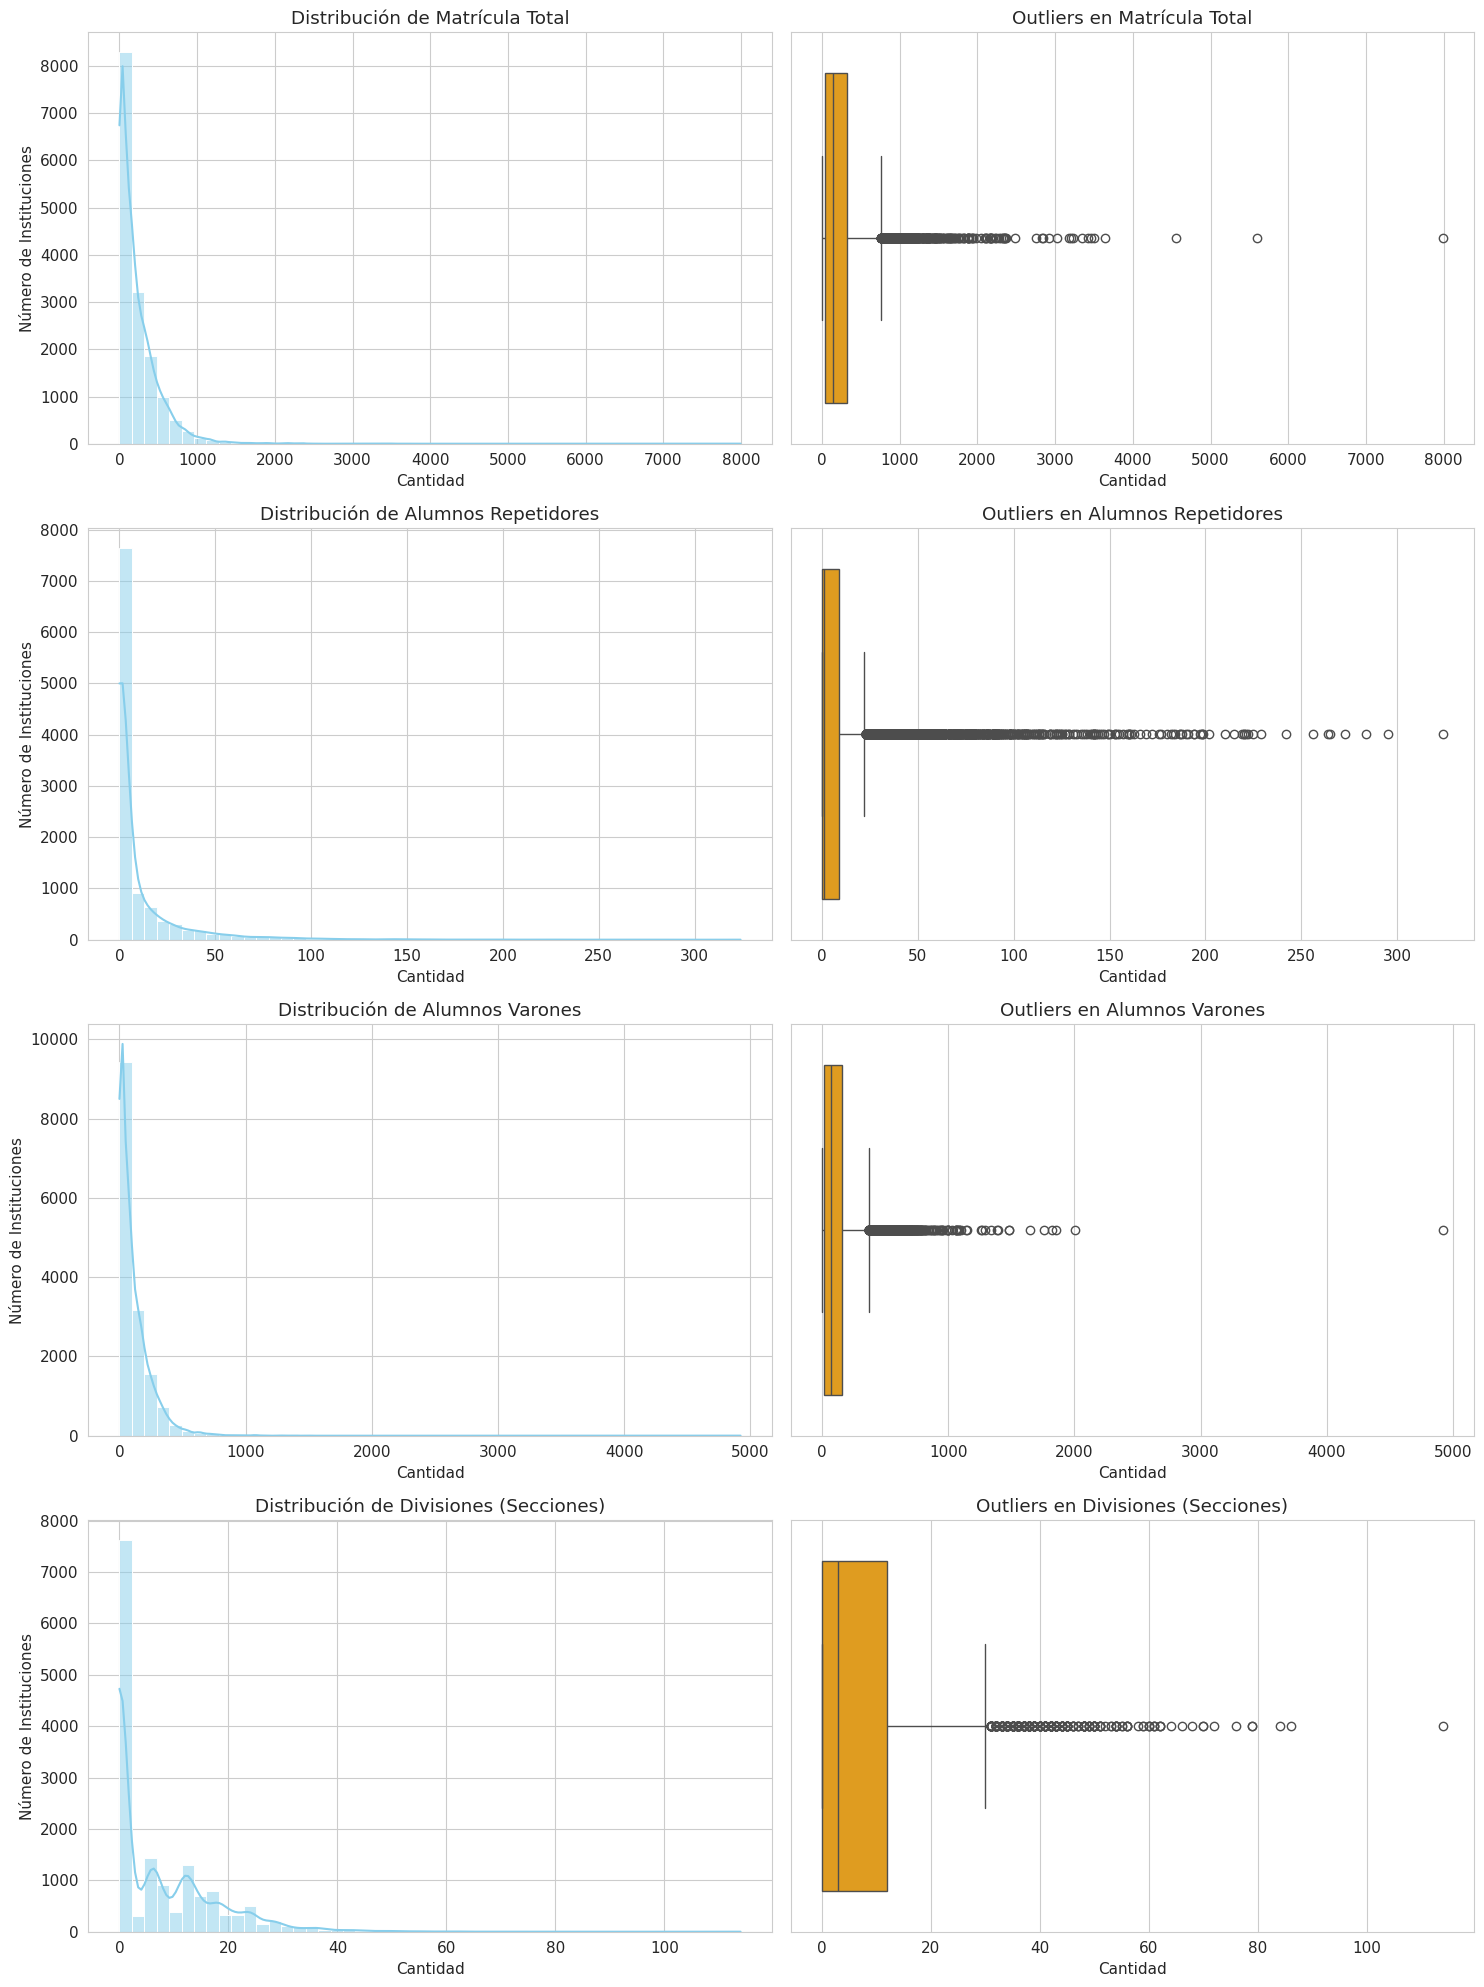

In [ ]:
#Graficar distribuciones (histogramas) y observar outliers mediante grafico de (boxplot).

# Definimos las variables a graficar para automatizar el proceso
variables = ['total_matricula', 'total_repetidores', 'total_varones', 'total_secciones']
titulos = ['Matrícula Total', 'Alumnos Repetidores', 'Alumnos Varones', 'Divisiones (Secciones)']


fig, axis = plt.subplots(4, 2, figsize=(15, 20)) #4 filas, 2 graficos.

for i, var in enumerate(variables):
    data_clean = df[var].dropna()

    # Histograma (Columna 0)
    sns.histplot(data_clean, bins=50, ax=axis[i, 0], color='skyblue', kde=True)
    axis[i, 0].set_title(f'Distribución de {titulos[i]}')
    axis[i, 0].set_xlabel('Cantidad')
    axis[i, 0].set_ylabel('Número de Instituciones')

    # Boxplot (Columna 1)
    sns.boxplot(x=data_clean, ax=axis[i, 1], color='orange')
    axis[i, 1].set_title(f'Outliers en {titulos[i]}')
    axis[i, 1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

Interpretación de gráficos:

(Matriculados)

Histograma: + de 30000 inst, tienen al menos 100 matriculados..

Boxplot: Si una institución tiene + 1000 matriculados, se considera 'outlier'.

(Repetidores)

Histograma: + de 25000 inst, tienen al menos 10 repetidores..

Boxplot: Si una institución tiene +25 repetidores, se considera 'outlier'.

(Varones)

Histograma: + de 30000 inst, tienen al menos 100 varones..

Boxplot: Si una institución tiene +365 varones, se considera 'outlier'.

(Secciones)

Histograma: La distribución suele variar, la cantidad de instituciones no depende de las divisiones que haya. La mayoria de inst, cuenta en general entre 0 y 5 diviciones.

Boxplot: Si una institución tiene al menos 30 divisiones (sumando todos los grados), se considera 'Outlier'...



In [ ]:
#Conteo de Outliers por caso
Outliers = df[variables] > upper_bound
print('Cantidad de Outliers: ', len(Outliers))

Outliers_Matriculados = Outliers['total_matricula'].sum()
print('Outliers (Matriculados): ', Outliers_Matriculados)

Outliers_Repetidores = Outliers['total_repetidores'].sum()
print('Outliers (Repetidores): ', Outliers_Repetidores)

Outliers_Varones = Outliers['total_varones'].sum()
print('Outliers (Varones): ', Outliers_Varones)

Outliers_Diviciones = Outliers['total_secciones'].sum()
print('Outliers (Diviciones): ', Outliers_Diviciones)

Cantidad de Outliers:  15448
Outliers (Matriculados):  675
Outliers (Repetidores):  1474
Outliers (Varones):  689
Outliers (Diviciones):  412


In [ ]:
#Mostrar 5 escuelas con mas cantidad de matriculados
# Pista: df.nlargest(5, 'matricula_total')
# Mostrar columnas relevantes: nombre_provincia (o 'provincia'), sector, ámbito, matricula_total

top5_mtr = df.nlargest(5, 'total_matricula')[['provincia','sector', 'ambito', 'total_matricula']]

top5_rpt = df.nlargest(5, 'total_repetidores')[['provincia', 'sector', 'ambito', 'total_repetidores']]

top5_vrs = df.nlargest(5, 'total_varones')[['provincia', 'sector', 'ambito', 'total_varones']]

top5_div = df.nlargest(5, 'total_secciones')[['provincia', 'sector', 'ambito', 'total_secciones']]

print('Top 5 Matriculados: ')
display(top5_mtr)

print('\nTop 5 Repetidores: ')
display(top5_rpt)

print('\nTop 5 Varones: ')
display(top5_vrs)

print('\nTop 5 Diviciones: ')
display(top5_div)

#El top 5 cuenta con al menos 5600 matr.

Top 5 Matriculados: 


,provincia,sector,ambito,total_matricula
13940,Ciudad de Buenos Aires,Privado,Urbano,7993.0
3679,Corrientes,Estatal,Urbano,5602.0
108,Ciudad de Buenos Aires,Estatal,Urbano,4561.0
9404,Tucumán,Estatal,Urbano,3647.0
14316,Mendoza,Estatal,Urbano,3498.0



Top 5 Repetidores: 


,provincia,sector,ambito,total_repetidores
2083,Salta,Estatal,Urbano,324.0
12988,Formosa,Estatal,Urbano,295.0
14148,Ciudad de Buenos Aires,Estatal,Urbano,284.0
15010,Salta,Estatal,Urbano,273.0
11585,San Juan,Estatal,Urbano,265.0



Top 5 Varones: 


,provincia,sector,ambito,total_varones
13940,Ciudad de Buenos Aires,Privado,Urbano,4922.0
3679,Corrientes,Estatal,Urbano,2005.0
14168,San Juan,Estatal,Urbano,1855.0
8695,Ciudad de Buenos Aires,Privado,Urbano,1819.0
108,Ciudad de Buenos Aires,Estatal,Urbano,1761.0



Top 5 Diviciones: 


,provincia,sector,ambito,total_secciones
8695,Ciudad de Buenos Aires,Privado,Urbano,114.0
3454,Ciudad de Buenos Aires,Estatal,Urbano,86.0
5456,Córdoba,Estatal,Urbano,84.0
9185,Ciudad de Buenos Aires,Estatal,Urbano,79.0
10739,Buenos Aires,Estatal,Urbano,79.0


In [ ]:
#Mostrar 5 escuelas con menor cantidad de matriculados

tail5_mtr = df.nsmallest(5, 'total_matricula')[['provincia','sector', 'ambito', 'total_matricula']]
tail5_rpt = df.nsmallest(5, 'total_repetidores')[['provincia','sector', 'ambito', 'total_repetidores']]
tail5_vrn = df.nsmallest(5, 'total_varones')[['provincia','sector', 'ambito', 'total_varones']]
tail5_div = df.nsmallest(5, 'total_secciones')[['provincia','sector', 'ambito', 'total_secciones']]

print('Top 5 (ultimos) Matriculados: ')
display(tail5_mtr)

print('\nTop 5 (ultimos) Repetidores: ')
display(tail5_rpt)

print('\nTop 5 (ultimos) Varones: ')
display(tail5_vrn)

print('\nTop 5 (ultimos) Diviciones: ')
display(tail5_div)

#El top 5 con menor matrc, cuenta solo con un matri.

Top 5 (ultimos) Matriculados: 


,provincia,sector,ambito,total_matricula
500,Córdoba,Estatal,Rural,1.0
616,Buenos Aires,Estatal,Rural,1.0
833,La Rioja,Estatal,Rural,1.0
834,La Rioja,Estatal,Rural,1.0
1027,Chaco,Estatal,Rural,1.0



Top 5 (ultimos) Repetidores: 


,provincia,sector,ambito,total_repetidores
0,Mendoza,Privado,Urbano,0.0
1,Santa Fe,Estatal,Rural,0.0
2,Catamarca,Estatal,Rural,0.0
3,Catamarca,Estatal,Rural,0.0
4,Catamarca,Estatal,Urbano,0.0



Top 5 (ultimos) Varones: 


,provincia,sector,ambito,total_varones
342,Buenos Aires,Privado,Urbano,0.0
368,Santa Fe,Estatal,Rural,0.0
438,Formosa,Estatal,Rural,0.0
535,Salta,Estatal,Rural,0.0
584,Buenos Aires,Estatal,Rural,0.0



Top 5 (ultimos) Diviciones: 


,provincia,sector,ambito,total_secciones
1,Santa Fe,Estatal,Rural,0.0
2,Catamarca,Estatal,Rural,0.0
3,Catamarca,Estatal,Rural,0.0
5,Santa Fe,Estatal,Rural,0.0
7,Santa Fe,Estatal,Urbano,0.0


* Observando las escuelas con mayor matrícula: ¿creen que son errores de carga de datos o son escuelas realmente muy grandes? Justifiquen usando el contexto del dominio.

Respuesta:

En la mayoría de los casos, se trata de escuelas reales con una matricula legitima, aunque se auditan legitimante. En Argentina, existen grandes unidades académicas, escuelas técnicas o "colegios nacionales", que cuentan con cantidades muy grande de alumnos, superarando los 4.000 o 5.000 alumnos para una sola institución, podría sospecharse de un error de duplicación o de la consolidación incorrecta de varios anexos en un solo registro.

* Observando las escuelas con menor matrícula positiva: ¿qué tipo de establecimientos podrían ser? (pista: pensar en zonas rurales, poblaciones pequeñas).

Respuesta:

Probablemente se trate de escuelas rurales, de frontera o de modalidad de educación técnica específica (baja densidad poblacional), incluso escuelas entre 15 y 20 alumnos aprox.

* Si ustedes tuvieran que hacer un análisis de matrícula promedio por provincia, ¿eliminarían los outliers o los conservarían? ¿Por qué? ¿Qué pasaría con el análisis en cada caso?

Respuesta:

si se eliminan, se perdería la representatividad de las grandes instituciones urbanas que atienden a una gran porción de la población escolar, lo que subestimaría la carga real del sistema en ciertas provincias.

In [ ]:
#Desbalanceo de categorias

# Mostrar la distribución de valores de la columna 'sector' (gestión estatal vs privada).

conteo_abs = df['sector'].value_counts()
conteo_porc = df['sector'].value_counts(normalize = True) * 100

#combinar
combinacion = pd.DataFrame ({
    'cantidad_absoluta ': conteo_abs,
    'Porcentaje (%) ': conteo_porc
})

print(combinacion)

#La gran mayoria de matriculados, se encuentran en el sector 'estatal'.

         cantidad_absoluta   Porcentaje (%) 
sector                                      
Estatal               12095        78.294925
Privado                3353        21.705075


In [ ]:
#Ambito

sec_ambito = df['ambito'].value_counts()
sec_porc = df['ambito'].value_counts(normalize = True) * 100

combinacion = pd.DataFrame ({
    'Cantidad_absoluta': sec_ambito,
    'Porcentaje (%)' : sec_porc
})
print(combinacion)

#Mayor volumen de matriculación en el sector urbano..

        Cantidad_absoluta  Porcentaje (%)
ambito                                   
Urbano              10275        66.51777
Rural                5172        33.48223


In [ ]:
# Mostrar cantidad de escuelas por provincia, ordenadas de mayor a menor.

cantidad_escuelas_xPrv = df['provincia'].value_counts().sort_values(ascending = False)


porcentaje = df['provincia'].value_counts(normalize = True) * 100

df_prov = pd.DataFrame({'Cantidad_escuelas': cantidad_escuelas_xPrv, 'Porcentaje': porcentaje})
df_prov

,Cantidad_escuelas,Porcentaje
provincia,,
Buenos Aires,4601,29.783791
Córdoba,1441,9.328068
Santa Fe,1080,6.991196
Chaco,795,5.146297
Misiones,651,4.214138
Entre Ríos,635,4.110564
Santiago del Estero,630,4.078198
Ciudad de Buenos Aires,628,4.065251
Mendoza,568,3.676851


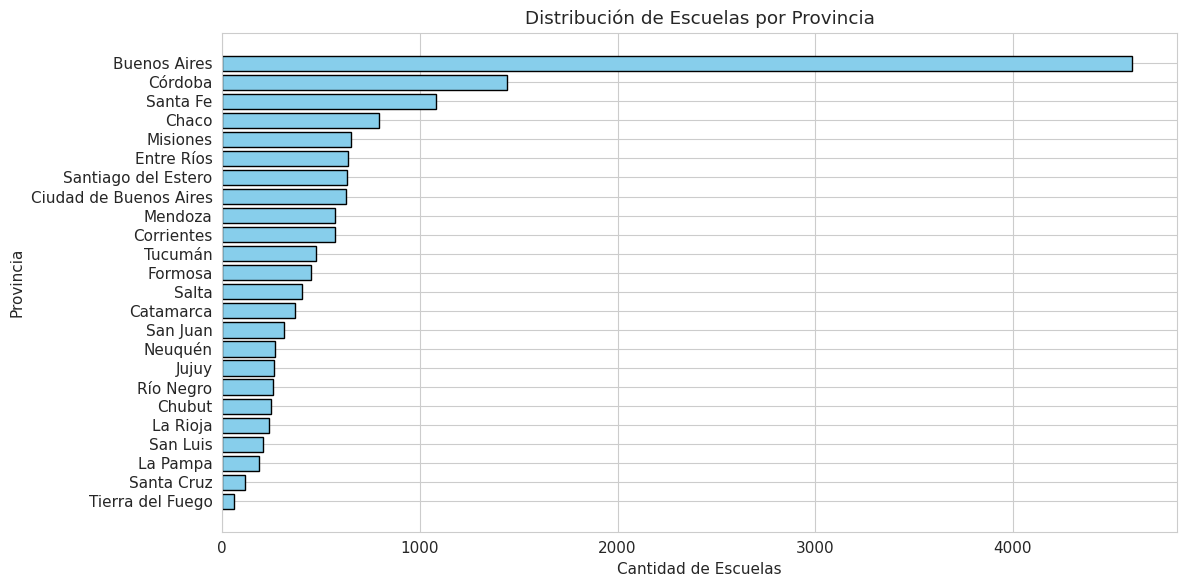

In [ ]:
#Visualizar la distribución por provincia en un gráfico de barras horizontales.

plt.figure(figsize = (12,6))

#plt.barh → barra horizontal
plt.barh(cantidad_escuelas_xPrv.index, cantidad_escuelas_xPrv.values, color = 'skyblue', edgecolor = 'black')
plt.gca().invert_yaxis()
plt.title('Distribución de Escuelas por Provincia')
plt.xlabel('Cantidad de Escuelas')
plt.ylabel('Provincia')

plt.tight_layout()
plt.show()

Pregunta 4.2.1: ¿Qué tan balanceadas están las distribuciones entre sector (estatal/privado) y ámbito (urbano/rural)?

**Respuesta**: Podemos notar que el ámbito 'Urbano' tiene más frecuencia de alumnos matriculados que el 'Rural'. Entendiendo por qué sucede esto, es que en la ciudad hay mayor número de población y por ende más escuelas. Las zonas rurales, a pesar de que si encontramos población, es mucho menos que la ciudad en cantidad de gente.

Pregunta 4.2.2: Buenos Aires concentra muchas más escuelas que otras provincias. ¿Esto es un problema del dataset o refleja la realidad del país? Pensar en cómo afectaría un análisis nacional.

**Respuesta**: Es un comportamiento real. En nuestro país, la provincia de Buenos Aires es la más poblada con diferencia que las demás provincias, incluso cuenta con 17 millones de habitantes (3 millones en capital federal), no es extraño que sea la provincia con más instituciones.

Pregunta 4.2.3: Si alguien quisiera estudiar las características de las escuelas rurales específicamente, ¿con cuántos datos contaría? ¿Es suficiente para sacar conclusiones robustas?

Respuesta: Para determinar con cuántos datos contarías, primero debemos realizar un filtrado sobre la columna ambito, que es la que clasifica a las instituciones en "Urbano" o "Rural" y ver como se comportan los datos en este ambito.

# Seccion 5: Inconsistencias y valores imposibles.

Hay valores que violan las reglas del dominio (edades negativas, porcentajes > 100%), duplicados, o codificaciones distintas para el mismo concepto.

In [ ]:
#Verificar si existen valores NEGATIVOS en alguna de las columnas numéricas clave.

print('Reporte de valores inconsistentes: ')

#Mejor hacer un blucle for, antes de ir columna * columna.
for col in variables:
  negativos = (df[col] < 0).sum()
  print(f'Columna ({col}): {negativos} filas con valores negativos')

Reporte de valores inconsistentes: 
Columna (total_matricula): 0 filas con valores negativos
Columna (total_repetidores): 0 filas con valores negativos
Columna (total_varones): 0 filas con valores negativos
Columna (total_secciones): 0 filas con valores negativos


In [ ]:
#Verificar filas donde la cantidad de REPETIDORES sea MAYOR que la matrícula total.

errores_repetidores = df[df['total_repetidores'] > df['total_matricula']]
cantidad_total = len(errores_repetidores)
print(f' Cantidad de filas donde (REPETIDORES > MATRICULA): {cantidad_total}')

#No hay filas donde haya mas repetidores, que matriculados.

 Cantidad de filas donde (REPETIDORES > MATRICULA): 0


In [ ]:
#Escuelas con matricula = 0 (escuelas sin alumnos).

sin_matriculados = df[df['total_matricula'] == 0]
escuelas_vacias = len(sin_matriculados)
print(f'Total de escuelas sin alumnnos: {escuelas_vacias}')

#Visualizar en que: (provincia, ambito y sectr se encuentra esta escuela)

if escuelas_vacias > 0:
  print('\nResumen de escuelas sin alumnos:')
  print(sin_matriculados[['provincia', 'sector', 'ambito']].value_counts())

Total de escuelas sin alumnnos: 0


In [ ]:
#Verificar si hay filas duplicadas en el dataset.

registros_duplicados = df.duplicated().sum()
print(f'Registros duplicados: {registros_duplicados}')

Registros duplicados: 0


In [ ]:
#verificar si hay identificadores repetidos (lo cual indicaría duplicación parcial).

identificadores_repetidos = [col for col in df.columns if col.lower() in ['ID1', 'cue', 'cueanexo', 'id_escuela']] #Identificadores unicos

duplicados = df[identificadores_repetidos].duplicated().sum()
print(f'Identificadores duplicados: {duplicados}')

Identificadores duplicados: 0


In [ ]:
#Explorar los valores únicos de la columna 'provincia'.

datos_unicos = sorted(df['provincia'].unique().tolist())
print(f'datos unicos en provincias: {datos_unicos}')

datos unicos en provincias: ['Buenos Aires', 'Catamarca', 'Chaco', 'Chubut', 'Ciudad de Buenos Aires', 'Corrientes', 'Córdoba', 'Entre Ríos', 'Formosa', 'Jujuy', 'La Pampa', 'La Rioja', 'Mendoza', 'Misiones', 'Neuquén', 'Río Negro', 'Salta', 'San Juan', 'San Luis', 'Santa Cruz', 'Santa Fe', 'Santiago del Estero', 'Tierra del Fuego', 'Tucumán']


# Reflexion sobre inconsistencias..

Pregunta 5.4.1: ¿Encontraron valores imposibles en el dataset? Si es así, describan cuáles y en qué columnas.

**Respuesta**: Por los resultados obtenidos, parece que no hay valores imposibles. No tenemos registros, ni identificadores duplicados y tampoco valores inconsistentes (como una matriculación negativa).

Pregunta 5.4.2: Si encontraron que algunos repetidores_total > matricula_total: ¿qué podría haber causado ese error? (pensar en el proceso de recolección de datos, formularios, carga manual).

Respuesta: En nuestro caso, esto no sucede por suerte. Si sucediera, el dataset sería un caos total, no tendría sentido que una institución tenga más repetidores que matriculados. El error podría ser causado por malos cálculos del administrador al registrar los datos.

Pregunta 5.4.3: ¿Las categorías (provincias, sectores, ámbitos) están codificadas de forma consistente? ¿Qué pasaría si no lo estuvieran? (ej: "Bs As" vs "Buenos Aires")

Respuesta: Exactamente. Todas las provincias están bien escritas, con mayúscula al principio y tilde donde corresponde. De todas formas, nosotros como estudiantes de lic en ciencia de datos, muchas veces hemos trabajado con dataset, que tienen columnas con nombres abreviados, por lo que dependiendo el caso, no nos molestaría. En este caso, al trabajar con provincias geográficas, creemos que sí es importante que sean consistentes.

# Sección 6: Variables redundantes o correlacionadas

In [ ]:
# Seleccionar las columnas numéricas clave y calcular su matriz de correlación.

colums_corr = ['total_matricula', 'total_repetidores', 'total_varones', 'total_secciones'] + mat_cols
matriz = df[colums_corr].corr()

print('Matriz de correlación: ')
display(matriz)

Matriz de correlación: 


,total_matricula,total_repetidores,total_varones,total_secciones,lactantes,deambulantes,s2,s3,s4,s5,_1,_2,_3,_4,_5,_6,_7,_8,_9,_10,_11,_12,_1314,_20,_snu
total_matricula,1.000000,0.437367,0.931068,0.755073,0.277095,0.280181,0.218695,0.419875,0.439417,0.459535,0.863116,0.861150,0.863553,0.868210,0.866814,0.867485,0.859995,0.846868,0.857100,0.855252,0.856276,0.850683,0.881887,0.046847,0.909469
total_repetidores,0.437367,1.000000,0.435774,0.460391,-0.350033,0.022145,0.010162,0.252252,0.299164,0.351896,0.378823,0.420104,0.415729,0.396290,0.395847,0.392513,0.510946,0.554873,0.560540,0.521631,0.446584,0.365605,0.325823,-0.105964,0.301938
total_varones,0.931068,0.435774,1.000000,0.816125,0.292893,0.301387,0.233091,0.453105,0.466990,0.490402,0.892827,0.893297,0.895894,0.899265,0.897483,0.898256,0.866213,0.845873,0.851418,0.842957,0.828810,0.811649,0.875032,-0.069476,0.752171
total_secciones,0.755073,0.460391,0.816125,1.000000,0.427256,0.370544,0.132668,0.081734,0.115493,0.160227,0.872352,0.877198,0.887605,0.886134,0.884123,0.887301,0.852183,0.857340,0.873270,0.875616,0.865967,0.850784,0.848334,-0.178804,-0.009440
lactantes,0.277095,-0.350033,0.292893,0.427256,1.000000,0.704579,0.437221,0.423453,0.348610,0.275914,0.461312,0.440068,0.541611,0.529081,0.475912,0.405117,0.440974,-0.006589,0.130077,0.122415,0.019464,0.138758,NaN,NaN,-1.000000
deambulantes,0.280181,0.022145,0.301387,0.370544,0.704579,1.000000,0.511025,0.431693,0.369574,0.333591,0.274236,0.386548,0.497661,0.453787,0.527892,0.458616,0.456223,0.202160,0.262916,0.213557,0.200513,0.339911,NaN,NaN,0.768478
s2,0.218695,0.010162,0.233091,0.132668,0.437221,0.511025,1.000000,0.745402,0.640436,0.605095,0.596986,0.599884,0.610734,0.581558,0.639189,0.601895,0.529486,0.381882,0.385407,0.470169,0.421309,0.463556,0.138383,NaN,-0.055560
s3,0.419875,0.252252,0.453105,0.081734,0.423453,0.431693,0.745402,1.000000,0.820325,0.788448,0.822758,0.829787,0.822716,0.816880,0.819405,0.819588,0.796252,0.527981,0.525150,0.489753,0.475895,0.516491,-0.078400,NaN,0.455402
s4,0.439417,0.299164,0.466990,0.115493,0.348610,0.369574,0.640436,0.820325,1.000000,0.938673,0.903404,0.892997,0.894366,0.889593,0.878036,0.875731,0.816236,0.618314,0.596125,0.547865,0.536802,0.565429,0.507117,NaN,0.464892
s5,0.459535,0.351896,0.490402,0.160227,0.275914,0.333591,0.605095,0.788448,0.938673,1.000000,0.948837,0.948070,0.944790,0.940533,0.932523,0.929788,0.866453,0.673574,0.645360,0.597708,0.588440,0.613733,0.516328,NaN,0.154060


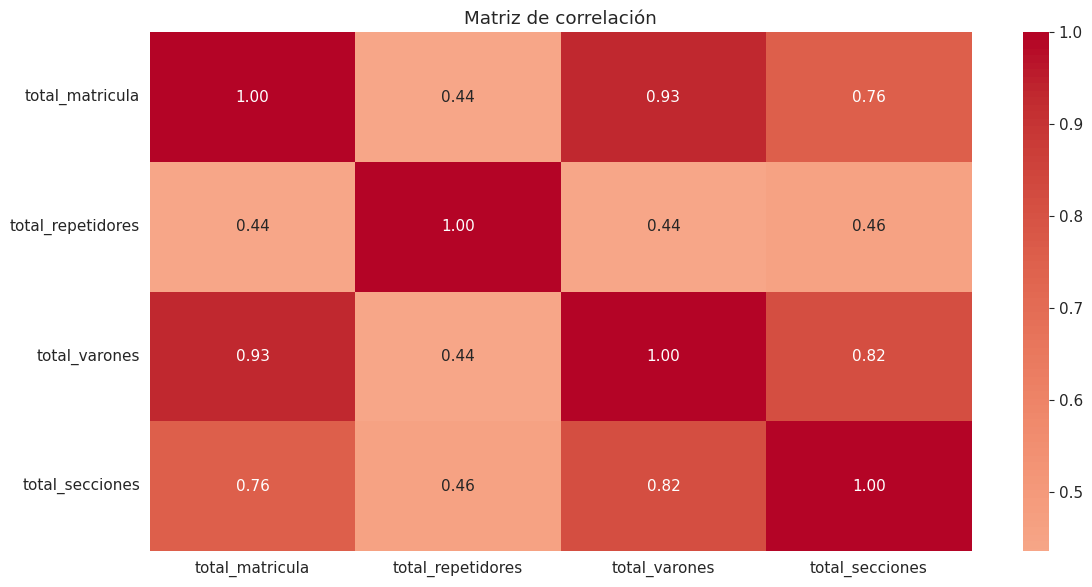

In [ ]:
#Visualizar la matriz de correlación como un heatmap de seaborn.
plt.figure(figsize = (12,6))
sns.heatmap(df[['total_matricula', 'total_repetidores','total_varones', 'total_secciones']].corr(), cmap = 'coolwarm', center = 0, fmt = '.2f', annot = True)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [ ]:
# [COMPLETAR] Identificar los pares de columnas con correlación MAYOR a 0.85 (en valor absoluto).
# Excluir la diagonal (correlación de una variable consigo misma = 1).
# Imprimir los pares y su correlación.

# Su código acá:
corr_abs = matriz.abs()
superior = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))  #excluir diagonal principal

pares_fuertes = superior.unstack().dropna()
pares_fuertes = pares_fuertes[pares_fuertes > 0.85].sort_values(ascending = False)

print('Pares de columnas con correlación absoluta > 0.85:')
print(pares_fuertes)

Pares de columnas con correlación absoluta > 0.85:
_snu   lactantes          1.000000
_4     _3                 0.976387
       _2                 0.974989
_6     _4                 0.974951
_3     _2                 0.974908
                            ...   
_1314  _9                 0.854729
_7     total_secciones    0.852183
_9     total_varones      0.851418
_12    total_secciones    0.850784
       total_matricula    0.850683
Length: 89, dtype: float64


**Reflexión sobre redundancia**

Pregunta 6.2.1: ¿Qué variables están altamente correlacionadas entre sí? ¿Tiene sentido lógico que lo estén?

Respuesta: las variables altamente correlacionadas son: '_snu' y 'lactantes' con corr: 1 (perfecta). Son redundantes, pero significan lo mismo (snu es un nombre técnico para la sala de lactantes). Después hay cursos seguidos (ej. 3-4 año) con alta correlación, indicando que si una sala tiene alta intensidad de alumnos, es seguro que la que siga sea parecida.

Pregunta 6.2.2: Si un futuro algoritmo de Machine Learning usará todas estas columnas como entrada, ¿por qué podría ser problemático? (pensar en que estarían aportando información duplicada).

Respuesta: Son muchas columnas altamente correlacionadas, esto podría confundir al modelo por la falta de redundancia individual.

Pregunta 6.2.3: Si tuvieran que quedarse con solo una de las columnas correlacionadas para un análisis posterior, ¿cuál elegirían y por qué?

**Respuesta**: elegiría la alta correlación entre los totales generales (matrículas-repetidores-secciones). Ya que incluyen información ramificada de los cursos. Es decir el total de estas características, es establecido por la información de los cursos.


# Seccion 7: sesgos de representación.

In [ ]:
#Calcular la matrícula promedio y la matrícula mediana POR SECTOR (estatal vs privado).

subgrupos_sector = df.groupby('sector')['total_matricula'].agg(['mean', 'median', 'count'])
print(subgrupos_sector)

               mean  median  count
sector                            
Estatal  210.370318   119.0  12095
Privado  299.058753   223.0   3353


In [ ]:
#Calcular la matrícula promedio POR ÁMBITO (urbano vs rural).
subgrupo_ambito = df.groupby('ambito')['total_matricula'].agg(['mean', 'median', 'count'])
print(subgrupo_ambito)

              mean  median  count
ambito                           
Rural    55.413573    22.0   5172
Urbano  317.329538   238.0  10275


In [ ]:
#Calcular la matrícula promedio POR PROVINCIA (top 10 -orden descen.)

subgrupo_provincia = df.groupby('provincia')['total_matricula'].agg(['mean']).sort_values(ascending = False, by = 'mean')
print(subgrupo_provincia.head(10))

                              mean
provincia                         
Ciudad de Buenos Aires  403.764331
Santa Cruz              340.094017
Salta                   322.466667
Mendoza                 284.262324
Neuquén                 283.929104
Tucumán                 272.040254
Buenos Aires            267.440339
Jujuy                   264.671756
Tierra del Fuego        256.220339
Río Negro               250.770428


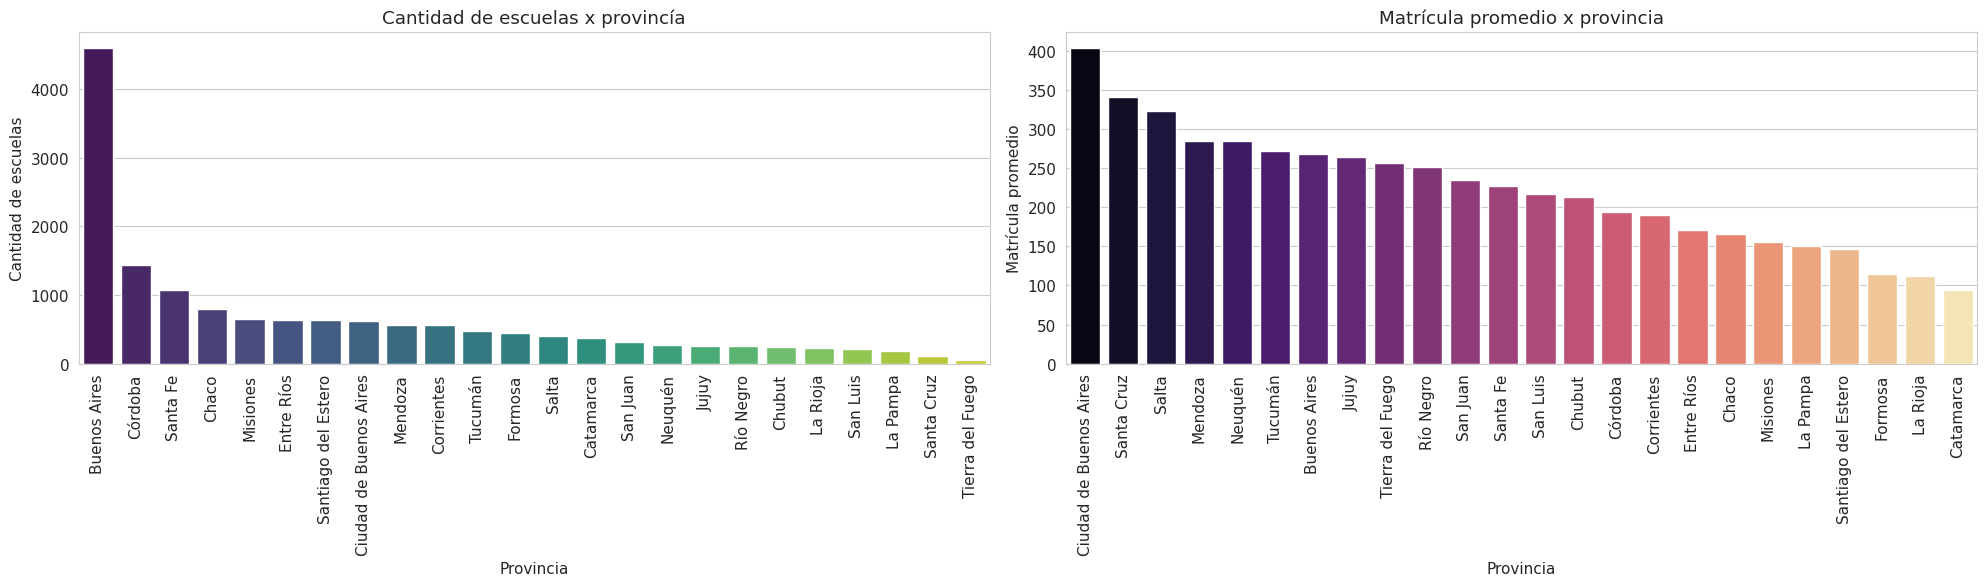

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (20,6))

sns.barplot(x = cantidad_escuelas_xPrv.index, y = cantidad_escuelas_xPrv.values, ax = axes[0], palette= 'viridis')
axes[0].set_title('Cantidad de escuelas x provincía')
axes[0].set_xlabel('Provincia')
axes[0].set_ylabel('Cantidad de escuelas')
axes[0].tick_params(axis = 'x', rotation = 90)

#Segundo grafico: matriculados promedio x provincia
sns.barplot(x = subgrupo_provincia.index, y = subgrupo_provincia['mean'], ax = axes[1], palette = 'magma')
axes[1].set_title('Matrícula promedio x provincia')
axes[1].set_xlabel('Provincia')
axes[1].set_ylabel('Matrícula promedio')
axes[1].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()
plt.show()



**Reflexión sobre sesgos**

Pregunta 7.2.1: ¿Hay diferencias sistemáticas entre escuelas estatales y privadas en términos de tamaño?

**Respuesta:**  Si nos referimos en términos de 'cantidades', si hay gran diferencia entre escuelas estatales y privadas. Hay más escuelas estatales que privadas, aunque el promedio de matriculados, es mayor en las escuelas privadas. Es más común encontrar densidad de escuelas privadas en zonas urbanas, donde se centra la mayoría de la población, además cuentan con mejor desempeño docente y servicios más estables.

Pregunta 7.2.2: Las escuelas rurales son menos en cantidad. ¿Qué implicancias tiene esto si alguien construye un análisis usando el dataset completo sin separar por ámbito? (pensar en que los patrones rurales podrían quedar enmascarados).

**Respuesta:** Si en un análisis, el ámbito no es relevante. Primero, no sería posible distinguir si la institución está en una zona urbana o rural. Los promedios y cálculos estadísticos 'tiran solo para un lado', donde más se centralizan los datos, esta sería una herramienta de utilidad, pero aún los resultados seguirán siendo sesgados representativamente.

Pregunta 7.2.3: Imaginen que quieren usar este dataset para construir un sistema de asignación de recursos educativos. ¿Qué riesgos éticos plantearía el desbalanceo entre provincias o entre ámbitos?

**Respuesta:** El desbalance de datos es un problema técnico que dificulta la posibilidad de entender cómo se comportan los datos. Si una provincia o ámbito (como el rural) tiene menos registros o datos más pobres, un algoritmo podría interpretarlo como una "menor demanda" o simplemente no entender sus necesidades, es como que 'lo perjudica sin razón´ → hay menos cantidad, pero no quiere decir que estos datos no sirvan.

In [ ]:
print('.......................')

## ***Parte 2: Tratamiento de Data Leakage***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print('Setup completo.')

Setup completo.


En esta parte vamos a entender por qué el 'Data Leakage' es un problema grave dentro del contexto de Machine Learning.

In [ ]:
work_area = 'Base 2 - Matrícula y secciones 2023.csv'
df_raw = pd.read_csv(work_area, sep=';', encoding='utf-8-sig', low_memory=False)

# Construir totales
mat_cols = [c for c in ['_1','_2','_3','_4','_5','_6','_7','_8','_9','_10','_11','_12','_1314','_snu'] if c in df_raw.columns]
rep_cols = [c for c in ['r_1','r_2','r_3','r_4','r_5','r_6','r_7','r_8','r_9','r_10','r_11','r_12','r_1314','r_20'] if c in df_raw.columns]
sec_cols = [c for c in ['_sec1','_sec2','_sec3','_sec4','_sec5','_sec6','_sec7','_sec8','_sec9','_sec10','_sec11','_sec12','_sec1314','_sec20'] if c in df_raw.columns]

df = df_raw.copy()
df['matricula_total']   = df[mat_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
df['repetidores_total'] = df[rep_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
df['secciones_total']   = df[sec_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)

In [ ]:
#Tasa de repitencia

df = df[(df['matricula_total'] > 0) & df['repetidores_total'].notna()].copy()
df['tasa_repitencia'] = df['repetidores_total'] / df['matricula_total']
df

#Target: nivel de repitencia

p33 = df['tasa_repitencia'].quantile(0.33)
p66 = df['tasa_repitencia'].quantile(0.66)
df['nivel_repitencia'] = pd.cut(df['tasa_repitencia'], bins=[-np.inf, p33, p66, np.inf], labels=['bajo','medio','alto'])

df = df.dropna(subset=['nivel_repitencia'])
df['nivel_repitencia'] = df['nivel_repitencia'].astype(str)

print(f'Escuelas: {len(df):.0f}')
print(f'\nTarget: Nivel_repitencia')
print(df['nivel_repitencia'].value_counts())

Escuelas: 35169

Target: Nivel_repitencia
nivel_repitencia
bajo     15611
alto     11958
medio     7600
Name: count, dtype: int64


Interpretación:

* Hay 15611 escuelas con baja tasa de repitencias.

In [ ]:
#Features leaking (incluye target dentro de las features)

features_leaking = ['matricula_total', 'secciones_total', 'tasa_repitencia', 'provincia', 'sector', 'ambito']
num_leak = ['matricula_total', 'secciones_total', 'tasa_repitencia']
cat_leak = ['provincia', 'ambito', 'sector']

X_leak = df[features_leaking].copy()
y      = df['nivel_repitencia']

X_train, X_test, y_train, y_test = train_test_split(
    X_leak, y, test_size=0.2, random_state=42, stratify=y
)

pre_leak = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_leak),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_leak)
])

pipe_leak = Pipeline([('pre', pre_leak), ('model', GradientBoostingClassifier(n_estimators=80, random_state=42))])
pipe_leak.fit(X_train, y_train)

acc_train_leak = accuracy_score(y_train, pipe_leak.predict(X_train))
acc_test_leak  = accuracy_score(y_test,  pipe_leak.predict(X_test))
f1_test_leak   = f1_score(y_test, pipe_leak.predict(X_test), average='macro')

print(f'=== CON LEAKAGE (tasa_repitencia como feature) ===')
print(f'Accuracy train: {acc_train_leak:.4f}')
print(f'Accuracy test:  {acc_test_leak:.4f}')
print(f'F1 macro test:  {f1_test_leak:.4f}')
print(f'Gap train-test: {acc_train_leak - acc_test_leak:.4f}')
print()
print('Resultado sospechosamente perfecto. Accuracy cercana a 1.0 es la firma típica de leakage.')
print('Problema: usamos la target como feature para realizar la predicción.')

=== CON LEAKAGE (tasa_repitencia como feature) ===
Accuracy train: 1.0000
Accuracy test:  1.0000
F1 macro test:  1.0000
Gap train-test: 0.0000

Resultado sospechosamente perfecto. Accuracy cercana a 1.0 es la firma típica de leakage.
Problema: usamos la target como feature para realizar la predicción.


In [ ]:
features_ok = ['matricula_total', 'secciones_total', 'provincia', 'sector', 'ambito'] #Ya no incluimos 'tasa_repetencia'.
num_ok = ['matricula_total', 'secciones_total']
cat_ok = ['provincia', 'sector', 'ambito']

X_ok = df[features_ok].copy()

X_train_ok, X_test_ok, y_train_ok, y_test_ok = train_test_split(
    X_ok, y, test_size=0.2, random_state=42, stratify=y
)

pre_ok = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_ok),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_ok)
])
pipe_ok = Pipeline([('pre', pre_ok), ('model', GradientBoostingClassifier(n_estimators=80, random_state=42))])
pipe_ok.fit(X_train_ok, y_train_ok)

acc_train_ok = accuracy_score(y_train_ok, pipe_ok.predict(X_train_ok))
acc_test_ok  = accuracy_score(y_test_ok,  pipe_ok.predict(X_test_ok))
f1_test_ok   = f1_score(y_test_ok, pipe_ok.predict(X_test_ok), average='macro')

print(f'=== SIN LEAKAGE (features legítimas) ===')
print(f'Accuracy train: {acc_train_ok:.4f}')
print(f'Accuracy test:  {acc_test_ok:.4f}')
print(f'F1 macro test:  {f1_test_ok:.4f}')
print(f'Gap train-test: {acc_train_ok - acc_test_ok:.4f}')
print()
print('Resultados mas modestos, pero realistas. Esto es lo que el modelo puede aprender honestamente.')

=== SIN LEAKAGE (features legítimas) ===
Accuracy train: 0.6218
Accuracy test:  0.6139
F1 macro test:  0.5670
Gap train-test: 0.0079

Resultados mas modestos, pero realistas. Esto es lo que el modelo puede aprender honestamente.


Comparación lado a lado:
                Con leakage  Sin leakage
Accuracy train          1.0       0.6218
Accuracy test           1.0       0.6139
F1 macro test           1.0       0.5670


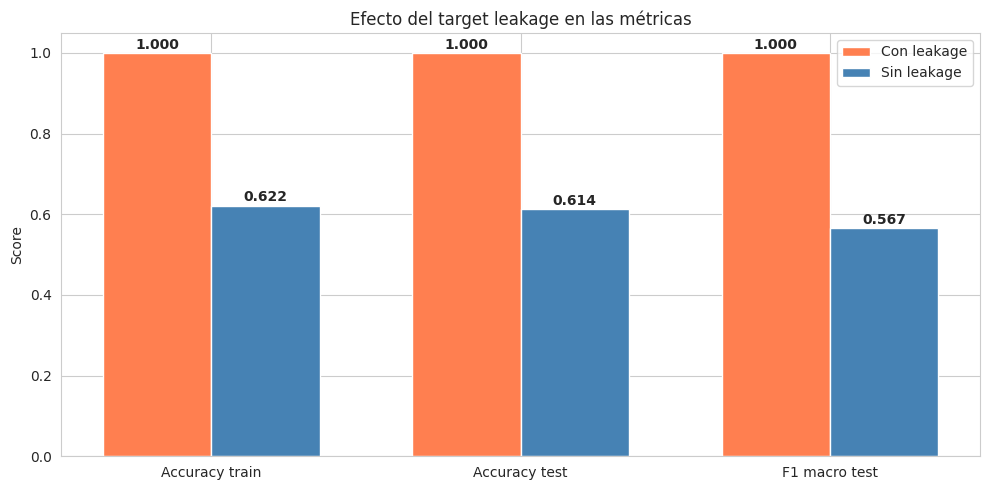


 Diagnóstico:
  - Con leakage: accuracy cercana a perfect → el modelo copia la información del target.
  - Sin leakage: accuracy realista → el modelo aprende patrones genuinos.
  - Si en tu proyecto ves accuracy > 0.98, sospechá de leakage antes de celebrar.


In [ ]:
#Visualización comparativa

comp = pd.DataFrame({
    'Con leakage':  [acc_train_leak, acc_test_leak, f1_test_leak],
    'Sin leakage':  [acc_train_ok,   acc_test_ok,   f1_test_ok]
}, index=['Accuracy train', 'Accuracy test', 'F1 macro test'])

print('Comparación lado a lado:')
print(comp.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp.index))
w = 0.35
ax.bar(x - w/2, comp['Con leakage'], w, label='Con leakage', color='coral')
ax.bar(x + w/2, comp['Sin leakage'], w, label='Sin leakage', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(comp.index)
ax.set_ylabel('Score')
ax.set_title('Efecto del target leakage en las métricas')
ax.legend()
ax.set_ylim(0, 1.05)
for i, (v1, v2) in enumerate(zip(comp['Con leakage'], comp['Sin leakage'])):
    ax.text(i - w/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontweight='bold')
    ax.text(i + w/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Diagnóstico:')
print('  - Con leakage: accuracy cercana a perfect → el modelo copia la información del target.')
print('  - Sin leakage: accuracy realista → el modelo aprende patrones genuinos.')
print('  - Si en tu proyecto ves accuracy > 0.98, sospechá de leakage antes de celebrar.')

# ***Parte 3 → inbalance de variables.***

Ahora vamos a notar por que el accuracy puede ser engañozo cuando las clases estan desbalancedas. En este tipo de casos es mejor creerle a resultados como: f1-macro, AUC-PR y MCC dado que son metricas mas honestas.

Escenario: identificar escuelas con tasa de repitencia extrema (>20%), que son una clase rara (~2-5% del total) → clase 0.

* Se define un Umbral a partir del 15%, si algun dato pasa esto, se lo coinsidera una 'escuela con repitencias extremas'.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef,
    precision_recall_curve, average_precision_score, roc_auc_score
)

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

ARCHIVO = 'Base 2 - Matrícula y secciones 2023.csv'
df_raw = pd.read_csv(ARCHIVO, sep=';', encoding='utf-8-sig', low_memory=False)

mat_cols = [c for c in ['_1','_2','_3','_4','_5','_6','_7','_8','_9','_10','_11','_12','_1314','_snu'] if c in df_raw.columns]
rep_cols = [c for c in ['r_1','r_2','r_3','r_4','r_5','r_6','r_7','r_8','r_9','r_10','r_11','r_12','r_1314','r_20'] if c in df_raw.columns]
sec_cols = [c for c in ['_sec1','_sec2','_sec3','_sec4','_sec5','_sec6','_sec7','_sec8','_sec9','_sec10','_sec11','_sec12','_sec1314','_sec20'] if c in df_raw.columns]

df = df_raw.copy()
df['matricula_total']   = df[mat_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
df['repetidores_total'] = df[rep_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
df['secciones_total']   = df[sec_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)

df = df[(df['matricula_total'] > 0) & df['repetidores_total'].notna()].copy()
df['tasa_repitencia'] = df['repetidores_total'] / df['matricula_total']

# Target BINARIO desbalanceado: escuelas con repitencia extrema (>15%)
UMBRAL = 0.15
df['repitencia_extrema'] = (df['tasa_repitencia'] > UMBRAL).astype(int)

print(f'Escuelas total: {len(df):,}')
print(f'Umbral de "repitencia extrema": {UMBRAL*100:.0f}%')
print(f'\nDistribución del target:')
counts = df['repitencia_extrema'].value_counts().sort_index()
print(f'  Clase 0 (normal):  {counts[0]:,} ({100*counts[0]/len(df):.1f}%)')
print(f'  Clase 1 (extrema): {counts[1]:,} ({100*counts[1]/len(df):.1f}%)')
print(f'\nRatio de desbalanceo: 1 caso extremo por cada {counts[0]/counts[1]:.1f} normales')
print('Solo el 7,2% de las escuelas, pasa el umbral (2525 casos).')

Escuelas total: 35,169
Umbral de "repitencia extrema": 15%

Distribución del target:
  Clase 0 (normal):  32,646 (92.8%)
  Clase 1 (extrema): 2,523 (7.2%)

Ratio de desbalanceo: 1 caso extremo por cada 12.9 normales
Solo el 7,2% de las escuelas, pasa el umbral (2525 casos).


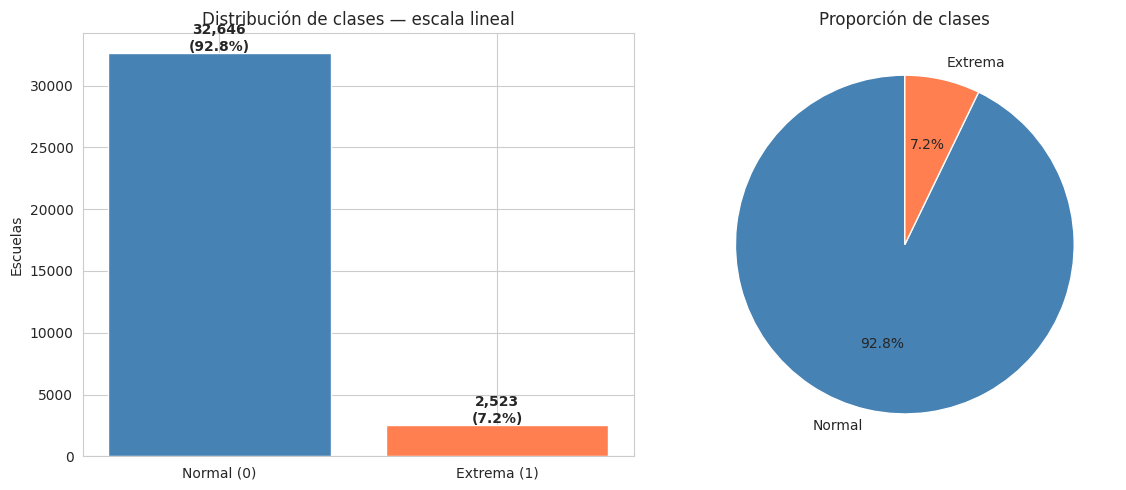

In [ ]:
# Visualizar el desbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Normal (0)', 'Extrema (1)'], counts.values, color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Distribución de clases — escala lineal')
axes[0].set_ylabel('Escuelas')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({100*v/len(df):.1f}%)', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Normal', 'Extrema'], autopct='%1.1f%%',
            colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()